https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-observing-strategies/nirspec-msata-reference-star-selection-recommended-strategies

need ~25 reference objects over the entire MSA, of which ~25% will likely be usable, yielding the ~6 we need.

In [1]:
#%matplotlib inline
%matplotlib notebook
import matplotlib.pyplot as plt

In [2]:
import os
import numpy as np
from glob import glob
from os.path import join
from os.path import expanduser
home = expanduser("~")

#from astropy.io import ascii
import astropy
from astropy.table import Table, vstack
import astropy.units as u

In [3]:
from PIL import Image, ImageEnhance
import PIL
PIL.Image.MAX_IMAGE_PIXELS = 933120000  # avoid decompression bomb error when loading large images

In [4]:
def roundint(x):
    return int(np.round(x))

def between(lo, x, hi):
    return (lo < x) * (x < hi)

# not detected: mag =  99; magerr = 1-sigma upper limit assuming zero flux
# not observed: mag = -99; magerr = 0
def fluxes2mags(flux, fluxerr):
    nondet = flux < 0  # Non-detection if flux is negative
    unobs = (fluxerr <= 0) + (fluxerr == np.inf)  # Unobserved if flux uncertainty is negative or infinity

    mag = flux.to(u.ABmag)
    magupperlimit = fluxerr.to(u.ABmag) # 1-sigma upper limit if flux=0

    mag = np.where(nondet, 99 * u.ABmag, mag)
    mag = np.where(unobs, -99 * u.ABmag, mag)

    magerr = 2.5 * np.log10(1 + fluxerr/flux) 
    magerr = magerr.value * u.ABmag

    magerr = np.where(nondet, magupperlimit, magerr)
    magerr = np.where(unobs, 0 * u.ABmag, magerr)
    
    return mag, magerr

def extract_id(cat, id, idlabel='id'):
    # Note input id must be same format as cat[idlabel] (int or string)
    # to create an array with mostly False entries and True for id
    # cat['id'] dtype='int64'
    # cat['id'] == 3: [False, False, True, False...]
    # cat['id'] == '3': False
    #
    # obj:          astropy.table.table.Table
    # obj[0]:       astropy.table.row.Row
    # obj['id']:    astropy.table.column.Column
    # obj[0]['id']: numpy.int64
    duck_duck_goose = cat[idlabel] == int(id)
    if len(duck_duck_goose):
        obj = cat[duck_duck_goose]
    return obj[0]

In [5]:
field = 'macs0647'
indir = os.path.join(home, field, 'catalogs', 'Vasily')
inroot = 'macs0647_acs'
infile = inroot + '_phot_apcorr.fits'
infile = os.path.join(indir, infile)
catalog = Table.read(infile)
catalog[:2]

id,thresh,npix,tnpix,xmin,xmax,ymin,ymax,x,y,x2_image,y2_image,xy_image,errx2,erry2,errxy,a_image,b_image,theta_image,cxx_image,cyy_image,cxy_image,cflux,flux,cpeak,peak,xcpeak,ycpeak,xpeak,ypeak,flag,x_image,y_image,number,ra,dec,x_world,y_world,flux_iso,fluxerr_iso,area_iso,mag_iso,kron_radius,kron_rcirc,flux_auto,fluxerr_auto,bkg_auto,flag_auto,area_auto,flux_radius_flag,flux_radius_20,flux_radius,flux_radius_90,tot_corr,mag_auto,magerr_auto,flux_aper_0,fluxerr_aper_0,flag_aper_0,bkg_aper_0,mask_aper_0,flux_aper_1,fluxerr_aper_1,flag_aper_1,bkg_aper_1,mask_aper_1,flux_aper_2,fluxerr_aper_2,flag_aper_2,bkg_aper_2,mask_aper_2,flux_aper_3,fluxerr_aper_3,flag_aper_3,bkg_aper_3,mask_aper_3,flux_aper_4,fluxerr_aper_4,flag_aper_4,bkg_aper_4,mask_aper_4,flux_aper_5,fluxerr_aper_5,flag_aper_5,bkg_aper_5,mask_aper_5,flux_aper_6,fluxerr_aper_6,flag_aper_6,bkg_aper_6,mask_aper_6,f105w_flux_aper_0,f105w_fluxerr_aper_0,f105w_flag_aper_0,f105w_bkg_aper_0,f105w_mask_aper_0,f105w_flux_aper_1,f105w_fluxerr_aper_1,f105w_flag_aper_1,f105w_bkg_aper_1,f105w_mask_aper_1,f105w_flux_aper_2,f105w_fluxerr_aper_2,f105w_flag_aper_2,f105w_bkg_aper_2,f105w_mask_aper_2,f105w_flux_aper_3,f105w_fluxerr_aper_3,f105w_flag_aper_3,f105w_bkg_aper_3,f105w_mask_aper_3,f105w_flag_aper_4,f105w_bkg_aper_4,f105w_mask_aper_4,f105w_flag_aper_5,f105w_bkg_aper_5,f105w_mask_aper_5,f105w_flag_aper_6,f105w_bkg_aper_6,f105w_mask_aper_6,f105w_tot_corr,f110w_flux_aper_0,f110w_fluxerr_aper_0,f110w_flag_aper_0,f110w_bkg_aper_0,f110w_mask_aper_0,f110w_flux_aper_1,f110w_fluxerr_aper_1,f110w_flag_aper_1,f110w_bkg_aper_1,f110w_mask_aper_1,f110w_flux_aper_2,f110w_fluxerr_aper_2,f110w_flag_aper_2,f110w_bkg_aper_2,f110w_mask_aper_2,f110w_flux_aper_3,f110w_fluxerr_aper_3,f110w_flag_aper_3,f110w_bkg_aper_3,f110w_mask_aper_3,f110w_flag_aper_4,f110w_bkg_aper_4,f110w_mask_aper_4,f110w_flag_aper_5,f110w_bkg_aper_5,f110w_mask_aper_5,f110w_flag_aper_6,f110w_bkg_aper_6,f110w_mask_aper_6,f110w_tot_corr,f115w-clear_flux_aper_0,f115w-clear_fluxerr_aper_0,f115w-clear_flag_aper_0,f115w-clear_bkg_aper_0,f115w-clear_mask_aper_0,f115w-clear_flux_aper_1,f115w-clear_fluxerr_aper_1,f115w-clear_flag_aper_1,f115w-clear_bkg_aper_1,f115w-clear_mask_aper_1,f115w-clear_flux_aper_2,f115w-clear_fluxerr_aper_2,f115w-clear_flag_aper_2,f115w-clear_bkg_aper_2,f115w-clear_mask_aper_2,f115w-clear_flux_aper_3,f115w-clear_fluxerr_aper_3,f115w-clear_flag_aper_3,f115w-clear_bkg_aper_3,f115w-clear_mask_aper_3,f115w-clear_flag_aper_4,f115w-clear_bkg_aper_4,f115w-clear_mask_aper_4,f115w-clear_flag_aper_5,f115w-clear_bkg_aper_5,f115w-clear_mask_aper_5,f115w-clear_flag_aper_6,f115w-clear_bkg_aper_6,f115w-clear_mask_aper_6,f115w-clear_tot_corr,f125w_flux_aper_0,f125w_fluxerr_aper_0,f125w_flag_aper_0,f125w_bkg_aper_0,f125w_mask_aper_0,f125w_flux_aper_1,f125w_fluxerr_aper_1,f125w_flag_aper_1,f125w_bkg_aper_1,f125w_mask_aper_1,f125w_flux_aper_2,f125w_fluxerr_aper_2,f125w_flag_aper_2,f125w_bkg_aper_2,f125w_mask_aper_2,f125w_flux_aper_3,f125w_fluxerr_aper_3,f125w_flag_aper_3,f125w_bkg_aper_3,f125w_mask_aper_3,f125w_flag_aper_4,f125w_bkg_aper_4,f125w_mask_aper_4,f125w_flag_aper_5,f125w_bkg_aper_5,f125w_mask_aper_5,f125w_flag_aper_6,f125w_bkg_aper_6,f125w_mask_aper_6,f125w_tot_corr,f140w_flux_aper_0,f140w_fluxerr_aper_0,f140w_flag_aper_0,f140w_bkg_aper_0,f140w_mask_aper_0,f140w_flux_aper_1,f140w_fluxerr_aper_1,f140w_flag_aper_1,f140w_bkg_aper_1,f140w_mask_aper_1,f140w_flux_aper_2,f140w_fluxerr_aper_2,f140w_flag_aper_2,f140w_bkg_aper_2,f140w_mask_aper_2,f140w_flux_aper_3,f140w_fluxerr_aper_3,f140w_flag_aper_3,f140w_bkg_aper_3,f140w_mask_aper_3,f140w_flag_aper_4,f140w_bkg_aper_4,f140w_mask_aper_4,f140w_flag_aper_5,f140w_bkg_aper_5,f140w_mask_aper_5,f140w_flag_aper_6,f140w_bkg_aper_6,f140w_mask_aper_6,f140w_tot_corr,f150w-clear_flux_aper_0,f150w-clear_fluxerr_aper_0,f150w-clear_flag_aper_0,f150w-clear_bkg_aper_0,f150w-clear_mask_aper_0,f150w-clear_flux_aper_1,f150w-clear_fluxerr_aper_1,f150w-clear_flag_aper_1,f150w-clear_bkg_aper_1,f150w-c

In [6]:
list(catalog.columns)

['id',
 'thresh',
 'npix',
 'tnpix',
 'xmin',
 'xmax',
 'ymin',
 'ymax',
 'x',
 'y',
 'x2_image',
 'y2_image',
 'xy_image',
 'errx2',
 'erry2',
 'errxy',
 'a_image',
 'b_image',
 'theta_image',
 'cxx_image',
 'cyy_image',
 'cxy_image',
 'cflux',
 'flux',
 'cpeak',
 'peak',
 'xcpeak',
 'ycpeak',
 'xpeak',
 'ypeak',
 'flag',
 'x_image',
 'y_image',
 'number',
 'ra',
 'dec',
 'x_world',
 'y_world',
 'flux_iso',
 'fluxerr_iso',
 'area_iso',
 'mag_iso',
 'kron_radius',
 'kron_rcirc',
 'flux_auto',
 'fluxerr_auto',
 'bkg_auto',
 'flag_auto',
 'area_auto',
 'flux_radius_flag',
 'flux_radius_20',
 'flux_radius',
 'flux_radius_90',
 'tot_corr',
 'mag_auto',
 'magerr_auto',
 'flux_aper_0',
 'fluxerr_aper_0',
 'flag_aper_0',
 'bkg_aper_0',
 'mask_aper_0',
 'flux_aper_1',
 'fluxerr_aper_1',
 'flag_aper_1',
 'bkg_aper_1',
 'mask_aper_1',
 'flux_aper_2',
 'fluxerr_aper_2',
 'flag_aper_2',
 'bkg_aper_2',
 'mask_aper_2',
 'flux_aper_3',
 'fluxerr_aper_3',
 'flag_aper_3',
 'bkg_aper_3',
 'mask_aper_3',

In [7]:
i = 1000
catalog['f814w_tot_1'][i] * u.uJy

<Quantity 4.1885505 uJy>

In [8]:
catalog['f814w_tot_2'][i] * u.uJy

<Quantity 4.18855098 uJy>

In [9]:
catalog['f814w_tot_3'][i] * u.uJy

<Quantity 4.18855185 uJy>

In [10]:
len(catalog)

3288

In [11]:
nothing = np.isnan(catalog['x'])
catalog = catalog[np.logical_not(nothing)]

In [12]:
len(catalog)

3288

In [13]:
catalog[:2]

id,thresh,npix,tnpix,xmin,xmax,ymin,ymax,x,y,x2_image,y2_image,xy_image,errx2,erry2,errxy,a_image,b_image,theta_image,cxx_image,cyy_image,cxy_image,cflux,flux,cpeak,peak,xcpeak,ycpeak,xpeak,ypeak,flag,x_image,y_image,number,ra,dec,x_world,y_world,flux_iso,fluxerr_iso,area_iso,mag_iso,kron_radius,kron_rcirc,flux_auto,fluxerr_auto,bkg_auto,flag_auto,area_auto,flux_radius_flag,flux_radius_20,flux_radius,flux_radius_90,tot_corr,mag_auto,magerr_auto,flux_aper_0,fluxerr_aper_0,flag_aper_0,bkg_aper_0,mask_aper_0,flux_aper_1,fluxerr_aper_1,flag_aper_1,bkg_aper_1,mask_aper_1,flux_aper_2,fluxerr_aper_2,flag_aper_2,bkg_aper_2,mask_aper_2,flux_aper_3,fluxerr_aper_3,flag_aper_3,bkg_aper_3,mask_aper_3,flux_aper_4,fluxerr_aper_4,flag_aper_4,bkg_aper_4,mask_aper_4,flux_aper_5,fluxerr_aper_5,flag_aper_5,bkg_aper_5,mask_aper_5,flux_aper_6,fluxerr_aper_6,flag_aper_6,bkg_aper_6,mask_aper_6,f105w_flux_aper_0,f105w_fluxerr_aper_0,f105w_flag_aper_0,f105w_bkg_aper_0,f105w_mask_aper_0,f105w_flux_aper_1,f105w_fluxerr_aper_1,f105w_flag_aper_1,f105w_bkg_aper_1,f105w_mask_aper_1,f105w_flux_aper_2,f105w_fluxerr_aper_2,f105w_flag_aper_2,f105w_bkg_aper_2,f105w_mask_aper_2,f105w_flux_aper_3,f105w_fluxerr_aper_3,f105w_flag_aper_3,f105w_bkg_aper_3,f105w_mask_aper_3,f105w_flag_aper_4,f105w_bkg_aper_4,f105w_mask_aper_4,f105w_flag_aper_5,f105w_bkg_aper_5,f105w_mask_aper_5,f105w_flag_aper_6,f105w_bkg_aper_6,f105w_mask_aper_6,f105w_tot_corr,f110w_flux_aper_0,f110w_fluxerr_aper_0,f110w_flag_aper_0,f110w_bkg_aper_0,f110w_mask_aper_0,f110w_flux_aper_1,f110w_fluxerr_aper_1,f110w_flag_aper_1,f110w_bkg_aper_1,f110w_mask_aper_1,f110w_flux_aper_2,f110w_fluxerr_aper_2,f110w_flag_aper_2,f110w_bkg_aper_2,f110w_mask_aper_2,f110w_flux_aper_3,f110w_fluxerr_aper_3,f110w_flag_aper_3,f110w_bkg_aper_3,f110w_mask_aper_3,f110w_flag_aper_4,f110w_bkg_aper_4,f110w_mask_aper_4,f110w_flag_aper_5,f110w_bkg_aper_5,f110w_mask_aper_5,f110w_flag_aper_6,f110w_bkg_aper_6,f110w_mask_aper_6,f110w_tot_corr,f115w-clear_flux_aper_0,f115w-clear_fluxerr_aper_0,f115w-clear_flag_aper_0,f115w-clear_bkg_aper_0,f115w-clear_mask_aper_0,f115w-clear_flux_aper_1,f115w-clear_fluxerr_aper_1,f115w-clear_flag_aper_1,f115w-clear_bkg_aper_1,f115w-clear_mask_aper_1,f115w-clear_flux_aper_2,f115w-clear_fluxerr_aper_2,f115w-clear_flag_aper_2,f115w-clear_bkg_aper_2,f115w-clear_mask_aper_2,f115w-clear_flux_aper_3,f115w-clear_fluxerr_aper_3,f115w-clear_flag_aper_3,f115w-clear_bkg_aper_3,f115w-clear_mask_aper_3,f115w-clear_flag_aper_4,f115w-clear_bkg_aper_4,f115w-clear_mask_aper_4,f115w-clear_flag_aper_5,f115w-clear_bkg_aper_5,f115w-clear_mask_aper_5,f115w-clear_flag_aper_6,f115w-clear_bkg_aper_6,f115w-clear_mask_aper_6,f115w-clear_tot_corr,f125w_flux_aper_0,f125w_fluxerr_aper_0,f125w_flag_aper_0,f125w_bkg_aper_0,f125w_mask_aper_0,f125w_flux_aper_1,f125w_fluxerr_aper_1,f125w_flag_aper_1,f125w_bkg_aper_1,f125w_mask_aper_1,f125w_flux_aper_2,f125w_fluxerr_aper_2,f125w_flag_aper_2,f125w_bkg_aper_2,f125w_mask_aper_2,f125w_flux_aper_3,f125w_fluxerr_aper_3,f125w_flag_aper_3,f125w_bkg_aper_3,f125w_mask_aper_3,f125w_flag_aper_4,f125w_bkg_aper_4,f125w_mask_aper_4,f125w_flag_aper_5,f125w_bkg_aper_5,f125w_mask_aper_5,f125w_flag_aper_6,f125w_bkg_aper_6,f125w_mask_aper_6,f125w_tot_corr,f140w_flux_aper_0,f140w_fluxerr_aper_0,f140w_flag_aper_0,f140w_bkg_aper_0,f140w_mask_aper_0,f140w_flux_aper_1,f140w_fluxerr_aper_1,f140w_flag_aper_1,f140w_bkg_aper_1,f140w_mask_aper_1,f140w_flux_aper_2,f140w_fluxerr_aper_2,f140w_flag_aper_2,f140w_bkg_aper_2,f140w_mask_aper_2,f140w_flux_aper_3,f140w_fluxerr_aper_3,f140w_flag_aper_3,f140w_bkg_aper_3,f140w_mask_aper_3,f140w_flag_aper_4,f140w_bkg_aper_4,f140w_mask_aper_4,f140w_flag_aper_5,f140w_bkg_aper_5,f140w_mask_aper_5,f140w_flag_aper_6,f140w_bkg_aper_6,f140w_mask_aper_6,f140w_tot_corr,f150w-clear_flux_aper_0,f150w-clear_fluxerr_aper_0,f150w-clear_flag_aper_0,f150w-clear_bkg_aper_0,f150w-clear_mask_aper_0,f150w-clear_flux_aper_1,f150w-clear_fluxerr_aper_1,f150w-clear_flag_aper_1,f150w-clear_bkg_aper_1,f150w-c

In [14]:
pixel_scale = 0.04
catalog['fwhm'] = 2 * catalog['flux_radius'] * pixel_scale

In [15]:
import astropy.units as u
from astropy.io import ascii
from astropy.io import fits
import astropy.wcs as wcs
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord

# Stellar colors

https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-observing-strategies/nirspec-msata-reference-star-selection-recommended-strategies/predicting-msata-reference-star-magnitudes

In [16]:
#star_colors = fits.open('candels_lookup_v2.fits')
star_colors = Table.read('candels_lookup_v2.fits')
star_colors[:2]

ID,Temperature,sigma_Temperature,log_g,sigma_log_g,Z,sigma_Z,EBV,sigma_EBV,color_uncert,color_resid,color_normerr,chisq,ndf,vimos_u,vimos_u_err,vimos_u_pred,megacam_u,megacam_u_err,megacam_u_pred,subaru_B,subaru_B_err,subaru_B_pred,acs_f435w,acs_f435w_err,acs_f435w_pred,megacam_g,megacam_g_err,megacam_g_pred,subaru_V,subaru_V_err,subaru_V_pred,megacam_r,megacam_r_err,megacam_r_pred,acs_f606w,acs_f606w_err,acs_f606w_pred,subaru_r,subaru_r_err,subaru_r_pred,subaru_Rc,subaru_Rc_err,subaru_Rc_pred,acs_f775w,acs_f775w_err,acs_f775w_pred,megacam_i,megacam_i_err,megacam_i_pred,subaru_i,subaru_i_err,subaru_i_pred,subaru_Ic,subaru_Ic_err,subaru_Ic_pred,acs_f814w,acs_f814w_err,acs_f814w_pred,megacam_z,megacam_z_err,megacam_z_pred,subaru_z,subaru_z_err,subaru_z_pred,acs_f850lp,acs_f850lp_err,acs_f850lp_pred,VISTA_Y,VISTA_Y_err,VISTA_Y_pred,WIRCAM_J,WIRCAM_J_err,WIRCAM_J_pred,VISTA_J,VISTA_J_err,VISTA_J_pred,UKIDSS_J,UKIDSS_J_err,UKIDSS_J_pred,ISAAC_J,ISAAC_J_err,ISAAC_J_pred,MOIRCS_J,MOIRCS_J_err,MOIRCS_J_pred,WIRCAM_H,WIRCAM_H_err,WIRCAM_H_pred,VISTA_H,VISTA_H_err,VISTA_H_pred,UKIDSS_H,UKIDSS_H_err,UKIDSS_H_pred,ISAAC_H,ISAAC_H_err,ISAAC_H_pred,MOIRCS_H,MOIRCS_H_err,MOIRCS_H_pred,WIRCAM_Ks,WIRCAM_Ks_err,WIRCAM_Ks_pred,VISTA_Ks,VISTA_Ks_err,VISTA_Ks_pred,UKIDSS_Ks,UKIDSS_Ks_err,UKIDSS_Ks_pred,ISAAC_Ks,ISAAC_Ks_err,ISAAC_Ks_pred,MOIRCS_Ks,MOIRCS_Ks_err,MOIRCS_Ks_pred,wfc3_f110w,wfc3_f110w_err,wfc3_f110w_pred,wfc3_f125w,wfc3_f125w_err,wfc3_f125w_pred,wfc3_f140w,wfc3_f140w_err,wfc3_f140w_pred,wfc3_f160w,wfc3_f160w_err,wfc3_f160w_pred,irac_ch1,irac_ch2,irac_ch1_err,irac_ch2_err,irac_ch1_pred,irac_ch2_pred,irac_ch1_contam,irac_ch2_contam,nirspec_f110w_pred,nirspec_f140x_pred,nirspec_clear_pred,nircam_f070w_pred,nircam_f090w_pred,nircam_f115w_pred,nircam_f140m_pred,nircam_f150w_pred,nircam_f150w2_pred,nircam_f162m_pred,nircam_f182m_pred,nircam_f200w_pred,nircam_f210m_pred,nircam_f250m_pred,nircam_f277w_pred,nircam_f300m_pred,nircam_f322w2_pred,nircam_f335m_pred,nircam_f356w_pred,nircam_f360m_pred,nircam_f410m_pred,nircam_f430m_pred,nircam_f444w_pred,nircam_f460m_pred,nircam_f480m_pred
bytes20,float32,float32,float32,float32,float32,float32,float32,float32,float32[3],float32[3],float32[3],float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
aegis_star_1,400.0,17400.0,0.0,0.188,-2.0,0.307,0.0,0.0,0.0141 .. 0.0141,0.8787 .. 0.4533,62.1 .. 32.1,27800.0,4.0,-1.0,-1.0,15.988798,16.846,0.01,17.158005,-1.0,-1.0,16.832088,-1.0,-1.0,16.890574,15.87,0.01,16.635286,-1.0,-1.0,16.382912,15.873,0.01,16.09526,16.868,0.01,16.210938,-1.0,-1.0,16.084702,-1.0,-1.0,16.00651,-1.0,-1.0,15.642404,16.346,0.01,15.647306,-1.0,-1.0,15.648611,-1.0,-1.0,15.568203,16.38,0.01,15.545308,15.179,0.01,15.332812,-1.0,-1.0,15.294915,-1.0,-1.0,15.29369,-1.0,-1.0,15.026589,-1.0,-1.0,14.583193,-1.0,-1.0,14.583807,-1.0,-1.0,14.588091,-1.0,-1.0,14.6136,-1.0,-1.0,14.585

In [17]:
list(star_colors.columns)

['ID',
 'Temperature',
 'sigma_Temperature',
 'log_g',
 'sigma_log_g',
 'Z',
 'sigma_Z',
 'EBV',
 'sigma_EBV',
 'color_uncert',
 'color_resid',
 'color_normerr',
 'chisq',
 'ndf',
 'vimos_u',
 'vimos_u_err',
 'vimos_u_pred',
 'megacam_u',
 'megacam_u_err',
 'megacam_u_pred',
 'subaru_B',
 'subaru_B_err',
 'subaru_B_pred',
 'acs_f435w',
 'acs_f435w_err',
 'acs_f435w_pred',
 'megacam_g',
 'megacam_g_err',
 'megacam_g_pred',
 'subaru_V',
 'subaru_V_err',
 'subaru_V_pred',
 'megacam_r',
 'megacam_r_err',
 'megacam_r_pred',
 'acs_f606w',
 'acs_f606w_err',
 'acs_f606w_pred',
 'subaru_r',
 'subaru_r_err',
 'subaru_r_pred',
 'subaru_Rc',
 'subaru_Rc_err',
 'subaru_Rc_pred',
 'acs_f775w',
 'acs_f775w_err',
 'acs_f775w_pred',
 'megacam_i',
 'megacam_i_err',
 'megacam_i_pred',
 'subaru_i',
 'subaru_i_err',
 'subaru_i_pred',
 'subaru_Ic',
 'subaru_Ic_err',
 'subaru_Ic_pred',
 'acs_f814w',
 'acs_f814w_err',
 'acs_f814w_pred',
 'megacam_z',
 'megacam_z_err',
 'megacam_z_pred',
 'subaru_z',
 'subaru_

In [18]:
from astropy.modeling import models, fitting
from astropy.stats import sigma_clip


In [19]:
def between(lo, x, hi):
    return (lo <= x) * (x <= hi)

In [20]:
color1 = star_colors['acs_f606w'] - star_colors['acs_f814w']
color2 = star_colors['acs_f814w'] - star_colors['nirspec_f140x_pred']

good1 = between(-10, color1, 10)
good2 = between(-10, color2, 10)
good = good1 * good2
color1 = color1[good]
color2 = color2[good]

x = np.arange(-1, 5, 0.01)
#y = x
#y
fit = fitting.LinearLSQFitter()
line_init = models.Linear1D()
robust_fit = fitting.FittingWithOutlierRemoval(fit, sigma_clip, niter=3, sigma=3.0)

fitted_line = fit(line_init, color1, color2)
robust_fitted_line, mask = robust_fit(line_init, color1, color2)

y = fitted_line(x)
robust_y = robust_fitted_line(x)

<IPython.core.display.Javascript object>


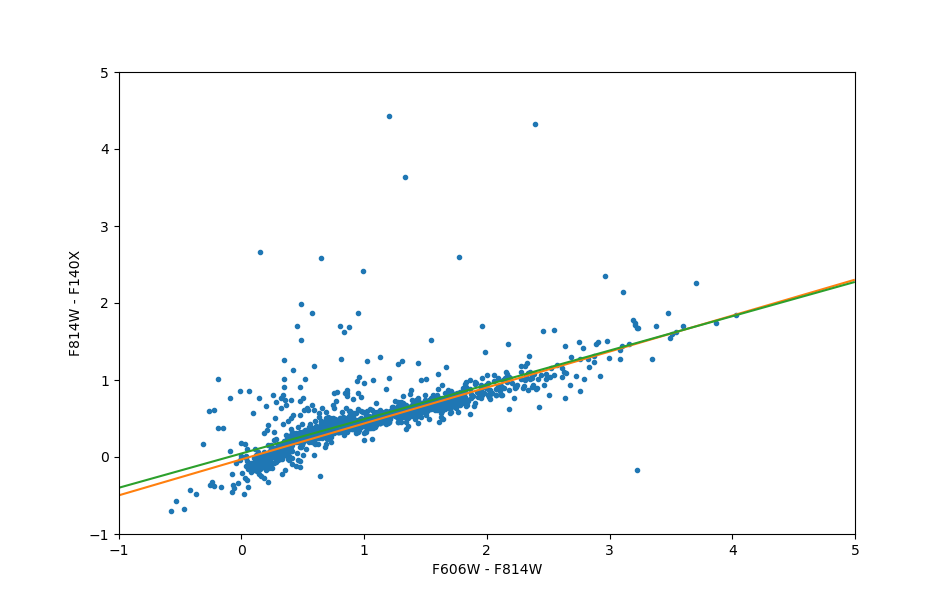

Text(0, 0.5, 'F814W - F140X')

In [21]:
fig = plt.figure(figsize=(9.5,6))
plt.plot(color1, color2, '.')
plt.plot(x, robust_y)
plt.plot(x, y)
plt.xlim(-1, 5)
plt.ylim(-1, 5)
plt.xlabel('F606W - F814W')
plt.ylabel('F814W - F140X')

In [22]:
f606w_mag = (catalog['f606w_tot_1']).to(u.ABmag)
f814w_mag = (catalog['f814w_tot_1']).to(u.ABmag)
r_i_colors = f606w_mag - f814w_mag
predicted_colors = robust_fitted_line(r_i_colors.value)

/Users/dcoe/miniconda3/envs/erophot/lib/python3.10/site-packages/astropy/units/function/logarithmic.py:47: RuntimeWarning: invalid value encountered in log10
  return dex.to(self._function_unit, np.log10(x))


In [23]:
# color = F814W - F140X
# F140X = F814W - color
f140x_mags = f814w_mag.value - predicted_colors
f140x_mags

array([nan, nan, nan, ..., nan, nan, nan])

In [24]:
catalog['F140X_predicted'] = f140x_mags * u.ABmag

# Find stars

In [28]:
mags = catalog['F140X_predicted'].value
mycat = catalog[between(0, mags, 90)]
mags = mycat['F140X_predicted'].value

<IPython.core.display.Javascript object>


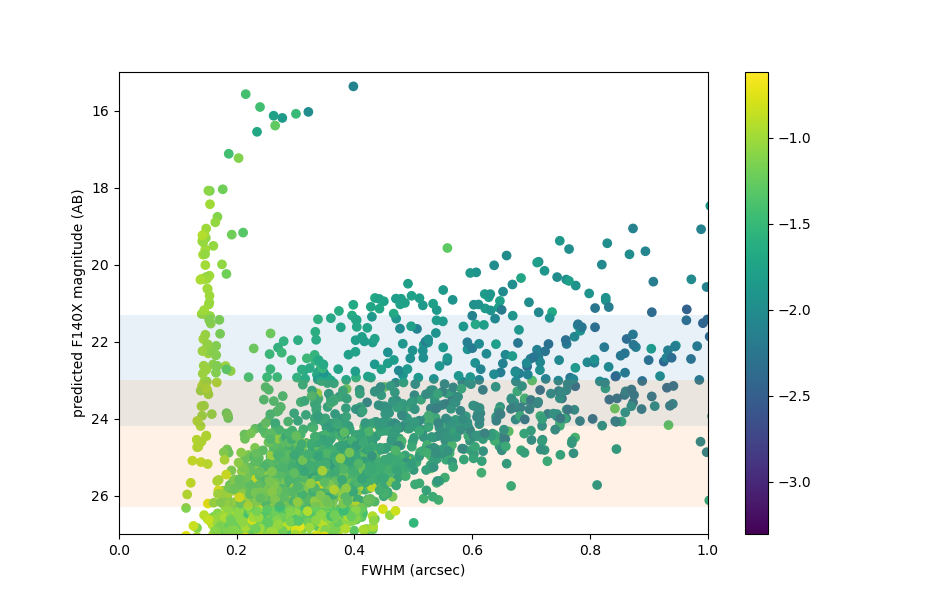

Text(0, 0.5, 'predicted F140X magnitude (AB)')

In [30]:
fig = plt.figure(figsize=(9.5,6))
#plt.plot(mycat['fwhm'], mycat['f110w_mag'], 'o')
#plt.scatter(mycat['fwhm'], mycat['f110w_mag'], c=mycat['stel'])
c = np.log10(mycat['peak'] / mycat['flux'])
#c = mycat['gini']
#plt.scatter(0.02*mycat['flux_radius'], mycat['f115w_mag'], c=c)
plt.scatter(mycat['fwhm'], mags, c=c)
#plt.fill_between([0, 1], 19.5, 22, alpha=0.1)  JDox v1.0 F110W
#plt.fill_between([0, 1], 21.3, 24, alpha=0.1)  JDox v1.0 F110W
#plt.fill_between([0, 1], 20.3, 23.2, alpha=0.1)  JDox v1.2 F110W
#plt.fill_between([0, 1], 22.0, 25.3, alpha=0.1)  JDox v1.0 F110W
plt.fill_between([0, 1], 21.3, 24.2, alpha=0.1)  # JDox v1.2 F140X NRSRAPID
plt.fill_between([0, 1], 23.0, 26.3, alpha=0.1)  # JDox v1.2 F140X NRSRAPID6
plt.colorbar()
#plt.colorbar(label='Stellarity')
plt.ylim(plt.ylim()[::-1])
plt.xlim(0,1)
#plt.xlim(0,0.5)
plt.ylim(30,18)
plt.ylim(27,15)
plt.xlabel('FWHM (arcsec)')
#plt.xlabel('Flux Radius (arcsec)')
plt.ylabel('predicted F140X magnitude (AB)')

In [31]:
# New good cat
#good_mag = between(21.3, mags, 24)
#good_mag = between(22.0, mags, 25.3)
#good_mag = between(21.3, catalog['F140X_predicted'], 24.2)
good_mag = between(21.8, catalog['F140X_predicted'], 24.2)  # not too close to saturation
compact = between(0.1, catalog['fwhm'].value, 0.2)
#compact = mycat['fwhm'].value < 0.2
good = good_mag * compact
good_cat = catalog[good]

In [32]:
#list(catalog.columns[-5:])

<IPython.core.display.Javascript object>


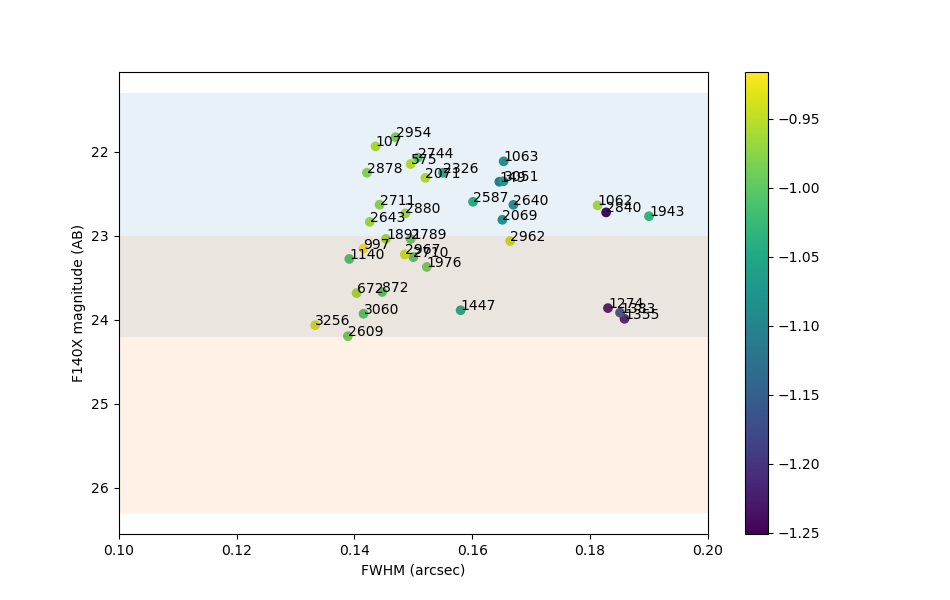

Text(0, 0.5, 'F140X magnitude (AB)')

In [33]:
fig = plt.figure(figsize=(9.5,6))
c = np.log10(good_cat['peak'] / good_cat['flux'])
plt.scatter(good_cat['fwhm'], good_cat['F140X_predicted'], c=c)
for i in range(len(good_cat)):
    color = 'k'
    id = good_cat['id'][i]
    if id in (3058, 3005, 1922):
        color = 'r'
        print(id, good_cat['F140X_predicted'][i])
    plt.text(good_cat['fwhm'][i], good_cat['F140X_predicted'][i], id, color=color)
    
plt.fill_between([0, 1], 21.3, 24.2, alpha=0.1)  # JDox v1.2 F140X
plt.fill_between([0, 1], 23.0, 26.3, alpha=0.1)  # JDox v1.2 F140X
plt.colorbar()
plt.ylim(plt.ylim()[::-1])
plt.xlim(0.1, 0.2)
#plt.ylim(24, 21)
plt.xlabel('FWHM (arcsec)')
plt.ylabel('F140X magnitude (AB)')

In [35]:
len(catalog[good]), len(catalog)

(36, 3288)

# Color images and inspection

In [36]:
#infile = '/Users/dcoe/RELICS/data/whl0137-08/epoch4/color/whl0137-08_new_bright.png' # HST
#infile = '/Users/dcoe/RELICS/data/whl0137-08/JWST/color/whl0137_v4_bright.png'
#infile = '/Users/dcoe/RELICS/data/whl0137-08/JWST/color/whl0137_hst3.png'
infile = 'macs0647_color_HST.png'
indir = os.path.join(home, field, 'color')
infile = os.path.join(indir, infile)
im = Image.open(infile)
imrgb = np.asarray(im)
imrgb = imrgb[::-1]

In [37]:
d_bright = 3.2 * u.arcsec
#within_box = distances < d_bright
#cat_coordinates[within_box]

In [38]:
pixel_scale = 0.04 * u.arcsec
d = d_bright / pixel_scale
d /= 2  # 3.2" box
d = roundint(d)
d

40

4 6.666666666666667


<IPython.core.display.Javascript object>


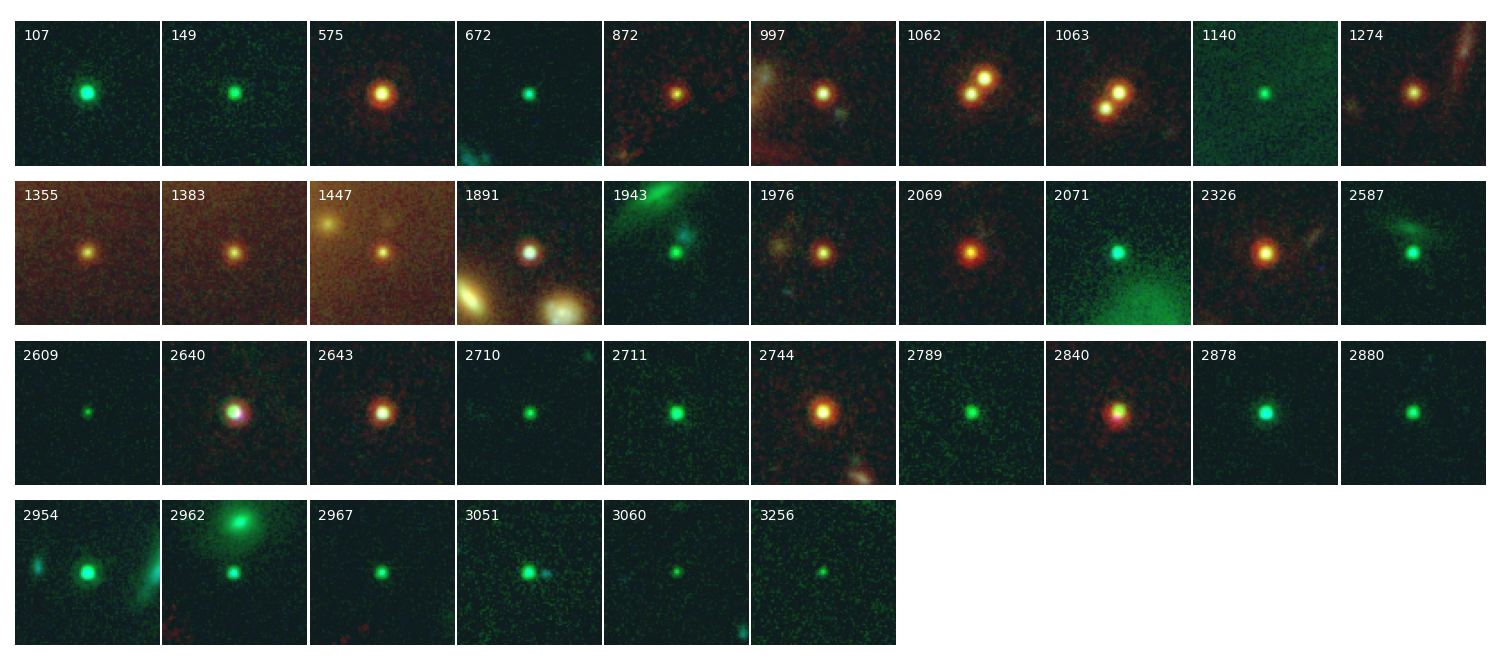

In [44]:
n = len(good_cat)
ncolumns = 10
nrows = np.ceil(n / ncolumns).astype(int)

figheight = 5 * nrows / 3.
print(nrows, figheight)

fig, ax = plt.subplots(nrows, ncolumns, figsize=(15,figheight))
ax = ax.flatten()

for i in range(ncolumns*nrows):
    ax[i].axis('off')
    
for i in range(n):
    x = roundint(good_cat['x'][i])
    y = roundint(good_cat['y'][i])
    extent = x-d-0.5, x+d+0.5, y-d-0.5, y+d+0.5
    ax[i].imshow(imrgb[y-d:y+d+1,x-d:x+d+1], origin='lower', extent=extent)
    ax[i].text(x-0.9*d,y+0.9*d, good_cat['id'][i], va='top', color='white')
    
plt.tight_layout()
plt.subplots_adjust(hspace=0.02, wspace=0.02)

# Check for bright neighbors

In [40]:
#good_cat_coordinates = SkyCoord(ra=good_cat['ra']*u.degree, dec=good_cat['dec']*u.degree)
good_cat_coordinates = SkyCoord(ra=good_cat['ra'], dec=good_cat['dec'])

In [41]:
good_cat_coordinates

<SkyCoord (ICRS): (ra, dec) in deg
    [(101.94278806, 70.2201751 ), (101.92613025, 70.22234022),
     (101.94929498, 70.23396958), (102.00581306, 70.23617894),
     (101.90063929, 70.23873865), (101.93782182, 70.24054656),
     (101.93452978, 70.24162283), (101.93429034, 70.24171868),
     (102.02865161, 70.24291875), (101.92991949, 70.24542973),
     (101.95934283, 70.24685988), (101.95563787, 70.24732272),
     (101.9532251 , 70.24833703), (101.93139233, 70.25409258),
     (101.90348002, 70.25419897), (101.94781312, 70.25528793),
     (101.93318617, 70.25648179), (101.86600698, 70.25642713),
     (101.98355494, 70.26018437), (102.03623142, 70.26447035),
     (101.90989625, 70.26505831), (101.98111212, 70.26543591),
     (101.93151297, 70.26547723), (101.91304389, 70.26688533),
     (101.8815213 , 70.26688624), (101.92540471, 70.26774997),
     (101.88351802, 70.26887055), (101.94339041, 70.27031871),
     (101.99795858, 70.27123855), (101.9870816 , 70.27130002),
     (101.93384186, 

In [42]:
d_bright = 3.2 * u.arcsec  # avoid brighter comapnions within 3.2"
d_faint  = 0.3 * u.arcsec  # avoid fainter  companions within 0.3"
# I'm going to make this a big bigger to get rid of 1063
d_faint  = 0.5 * u.arcsec  # avoid fainter  companions within 0.5"

In [45]:
brightest_in_big_box = np.ones(n)
alone_in_small_box   = np.ones(n)
#mag = good_cat['segment_mag'].value
mag = good_cat['F140X_predicted'].value

for i in range(len(good_cat)):
    obj_coordinates = SkyCoord(ra=good_cat['ra'][i]*u.degree, dec=good_cat['dec'][i]*u.degree)
    #obj_coordinates = SkyCoord(ra=good_cat['ra'][i], dec=good_cat['dec'][i])
    distances = obj_coordinates.separation(good_cat_coordinates)
    
    within_box = distances < d_bright
    within_box = within_box * (distances > 0)  # exclude self (distance = 0)
    idxcatalog = np.where(within_box)[0]
    if np.any(within_box):
        brightest_in_big_box[i] = mag[i] < np.min(mag[idxcatalog])
    
    within_small_box = distances < d_faint
    within_small_box = within_small_box * (distances > 0)  # exclude self (distance = 0)    
    if np.any(within_small_box):
        alone_in_small_box[i] = False
        
    print(i, good_cat['id'][i], '%.2f' % mag[i], brightest_in_big_box[i], alone_in_small_box[i])

0 107 21.94 1.0 1.0
1 149 22.36 1.0 1.0
2 575 22.15 1.0 1.0
3 672 23.68 1.0 1.0
4 872 23.67 1.0 1.0
5 997 23.15 1.0 1.0
6 1062 22.64 0.0 0.0
7 1063 22.11 1.0 0.0
8 1140 23.28 1.0 1.0
9 1274 23.86 1.0 1.0
10 1355 23.99 1.0 1.0
11 1383 23.91 1.0 1.0
12 1447 23.89 1.0 1.0
13 1891 23.04 1.0 1.0
14 1943 22.77 1.0 1.0
15 1976 23.37 1.0 1.0
16 2069 22.81 1.0 1.0
17 2071 22.31 1.0 1.0
18 2326 22.25 1.0 1.0
19 2587 22.60 1.0 1.0
20 2609 24.19 1.0 1.0
21 2640 22.63 1.0 1.0
22 2643 22.83 1.0 1.0
23 2710 23.25 1.0 1.0
24 2711 22.63 1.0 1.0
25 2744 22.07 1.0 1.0
26 2789 23.04 1.0 1.0
27 2840 22.72 1.0 1.0
28 2878 22.25 1.0 1.0
29 2880 22.73 1.0 1.0
30 2954 21.83 1.0 1.0
31 2962 23.06 1.0 1.0
32 2967 23.22 1.0 1.0
33 3051 22.35 1.0 1.0
34 3060 23.93 1.0 1.0
35 3256 24.06 1.0 1.0


In [46]:
all_good = brightest_in_big_box * alone_in_small_box

In [47]:
np.sum(brightest_in_big_box), np.sum(alone_in_small_box), np.sum(all_good), len(all_good)

(35.0, 34.0, 34.0, 36)

# Manually prune

In [79]:
good_star_cat = good_cat[all_good.astype(bool)]
len(good_star_cat)

34

In [80]:
bad_ids = 1943, 2587, 3051  # 1447, 2071, 2840, 2789
good_ids = list(set(good_star_cat['id']) - set(bad_ids))
set(good_star_cat['id']) - set(good_ids)

{1943, 2587, 3051}

In [81]:
set(good_ids) - set(good_star_cat['id'])  # Any typos?

set()

In [82]:
good_star_cat = catalog[np.array(good_ids) - 1]
len(good_star_cat)

31

4 7.500000000000002


<IPython.core.display.Javascript object>


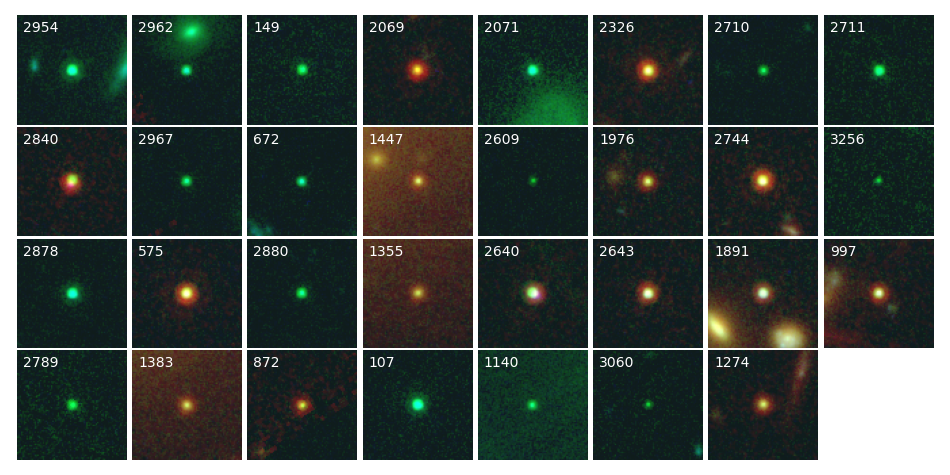

In [83]:
n = len(good_star_cat)
ncolumns = 8
nrows = np.ceil(n / ncolumns).astype(int)

fig_width = 9.5
fig_height = 5 * nrows / 3. * 10 / 8. * 0.9 * fig_width / 15.
print(nrows, figheight)

fig, ax = plt.subplots(nrows, ncolumns, figsize=(fig_width,fig_height))
ax = ax.flatten()

for i in range(ncolumns*nrows):
    ax[i].axis('off')
    
for i in range(n):
    x = roundint(good_star_cat['x'][i])
    y = roundint(good_star_cat['y'][i])
    extent = x-d-0.5, x+d+0.5, y-d-0.5, y+d+0.5
    ax[i].imshow(imrgb[y-d:y+d+1,x-d:x+d+1], origin='lower', extent=extent)
    ax[i].text(x-0.9*d,y+0.9*d, good_star_cat['id'][i], va='top', color='white')
    
plt.tight_layout()
plt.subplots_adjust(hspace=0.02, wspace=0.02)

In [84]:
len(good_star_cat)

31

In [85]:
plt.savefig('macs0647_reference_object_candidates_hst.png')

In [87]:
# They're all good; cut to it:
good_cat.write(field+'_reference_objects_hst.ecsv')